[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Seminar%2002/Seminar%2002.ipynb)

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Define stock symbols
stocks = ['AAPL', 'MSFT', 'GOOGL']  # Example stocks
start_date = '2020-01-01'
end_date = '2025-02-28'

In [3]:
# Download stock data
prices = yf.download(stocks, start=start_date, end=end_date)[['Open', 'High', 'Low', 'Close']]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


In [4]:
# Define colors for stocks
colors = {'AAPL': 'blue', 'MSFT': 'green', 'GOOGL': 'red'}

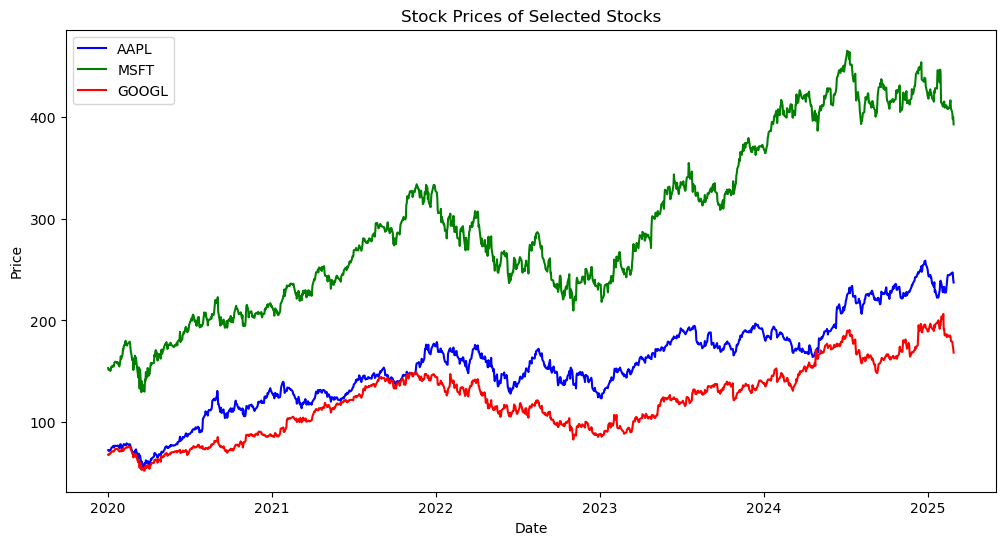

In [5]:
# Plot stock prices
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(prices.index, prices['Close'][stock], label=stock, color=colors[stock])
plt.title('Stock Prices of Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [6]:
# Compute log returns
log_returns = np.log(prices['Close'] / prices['Close'].shift(1)).dropna()

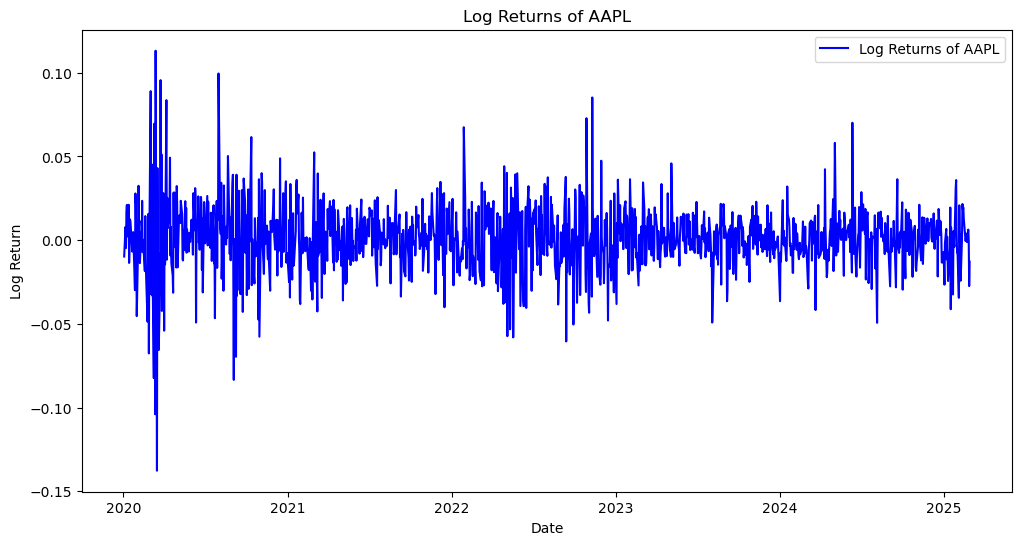

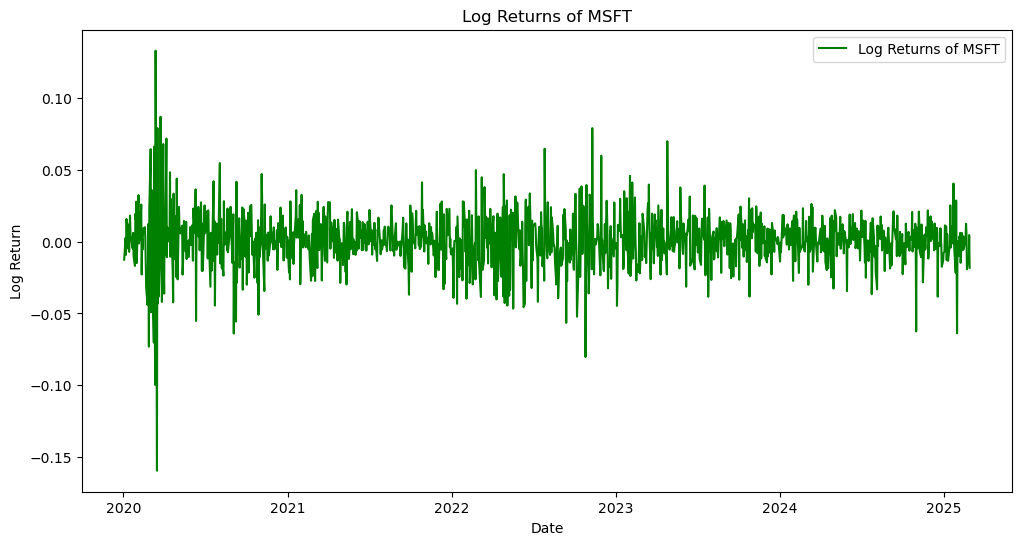

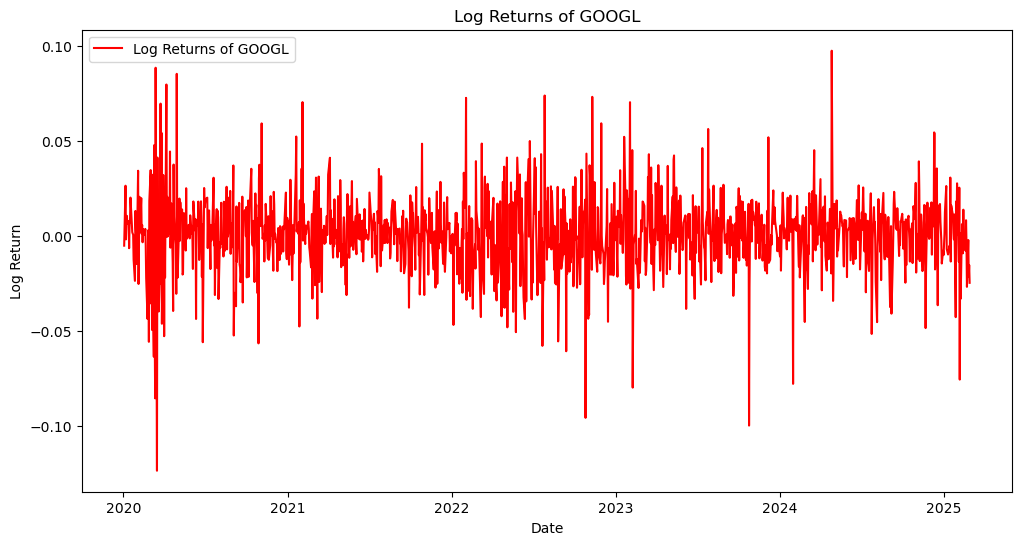

In [7]:
# Plot log returns separately
for stock in stocks:
    plt.figure(figsize=(12, 6))
    plt.plot(log_returns.index, log_returns[stock], label=f'Log Returns of {stock}', color=colors[stock])
    plt.title(f'Log Returns of {stock}')
    plt.xlabel('Date')
    plt.ylabel('Log Return')
    plt.legend()
    plt.show()

In [8]:
# Compute cumulative log returns
cumulative_log_returns = log_returns.cumsum()

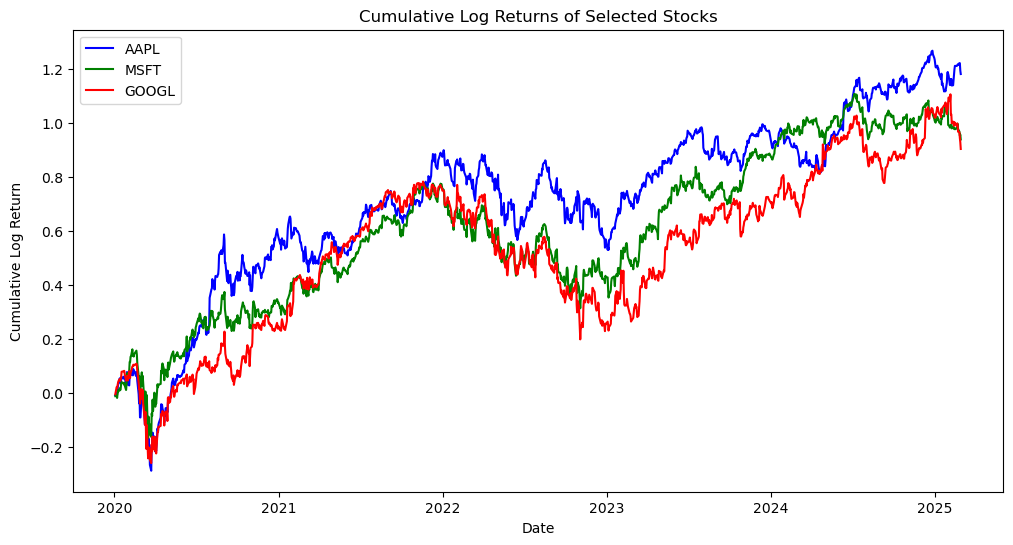

In [9]:
# Plot Cumulative Log Returns
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(cumulative_log_returns.index, cumulative_log_returns[stock], label=stock, color=colors[stock])
plt.title('Cumulative Log Returns of Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Return')
plt.legend()
plt.show()

In [10]:
# Define rolling window
rolling_window = 60  # 22-day rolling window

In [11]:
# Realized Volatility
def realized_volatility(log_returns, window=rolling_window):
    return log_returns.rolling(window=window).std() * np.sqrt(252)

realized_vol = realized_volatility(log_returns)

In [12]:
# Historical Volatility using Variance Formula
def historical_volatility(log_returns, window=rolling_window):
    mean_return = log_returns.rolling(window=window).mean()
    variance = ((log_returns - mean_return) ** 2).rolling(window=window).sum() / (window - 1)
    return np.sqrt(variance) * np.sqrt(252)

hist_vol = historical_volatility(log_returns)

In [13]:
# Parkinson's Volatility
def parkinson_volatility(high, low, window=rolling_window):
    return np.sqrt((1 / (4 * np.log(2))) * (np.log(high / low) ** 2).rolling(window=window).mean()) * np.sqrt(252)

parkinson_vol = pd.DataFrame({stock: parkinson_volatility(prices['High'][stock], prices['Low'][stock]) for stock in stocks})

In [14]:
# Garman-Klass Volatility
def garman_klass_volatility(open_, high, low, close, window=rolling_window):
    return np.sqrt(((0.5 * (np.log(high / low))**2) - (2 * np.log(2) - 1) * (np.log(close / open_))**2).rolling(window=window).mean()) * np.sqrt(252)

garman_klass_vol = pd.DataFrame({
    stock: garman_klass_volatility(prices['Open'][stock], prices['High'][stock], prices['Low'][stock], prices['Close'][stock]) for stock in stocks
})

In [15]:
# Rogers-Satchell Volatility
def rogers_satchell_volatility(open_, high, low, close, window=rolling_window):
    return np.sqrt(((np.log(high / open_) * np.log(high / close)) + (np.log(low / open_) * np.log(low / close))).rolling(window=window).mean()) * np.sqrt(252)

rogers_satchell_vol = pd.DataFrame({
    stock: rogers_satchell_volatility(prices['Open'][stock], prices['High'][stock], prices['Low'][stock], prices['Close'][stock]) for stock in stocks
})

In [16]:
# Yang-Zhang Volatility
def yang_zhang_volatility(open_, high, low, close, log_returns, window=rolling_window):
    yz_vol = {}
    for stock in stocks:
        k = 0.34 / (1.34 + (window + 1) / (window - 1))
        close_vol = log_returns[stock].rolling(window=window).var()
        open_vol = (np.log(open_[stock] / close.shift(1)[stock])).rolling(window=window).var()
        rs_vol = ((np.log(high[stock] / close[stock]) * np.log(high[stock] / open_[stock])) + (np.log(low[stock] / close[stock]) * np.log(low[stock] / open_[stock]))).rolling(window=window).var()
        yz_vol[stock] = np.sqrt(close_vol + k * open_vol + (1 - k) * rs_vol) * np.sqrt(252)
    return pd.DataFrame(yz_vol)

yang_zhang_vol = yang_zhang_volatility(prices['Open'], prices['High'], prices['Low'], prices['Close'], log_returns)

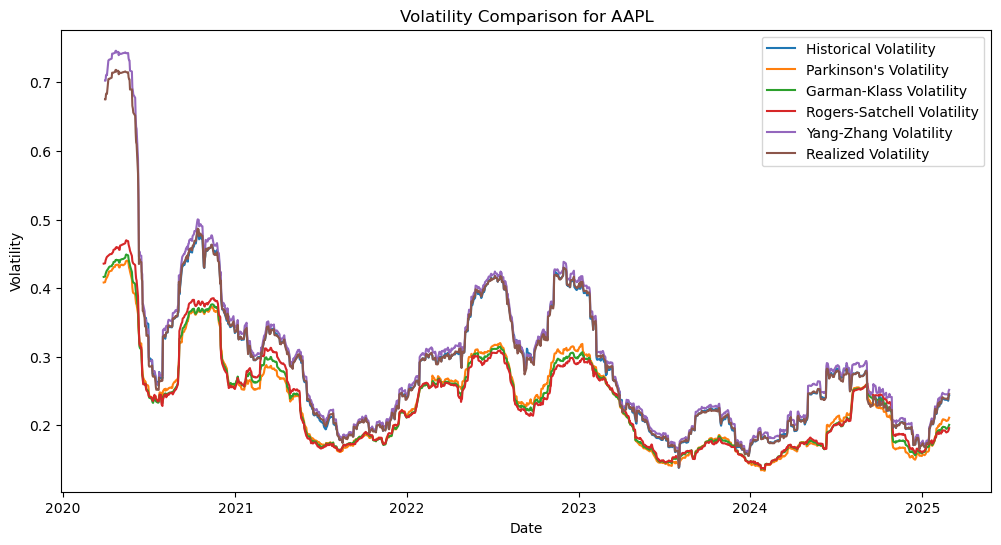

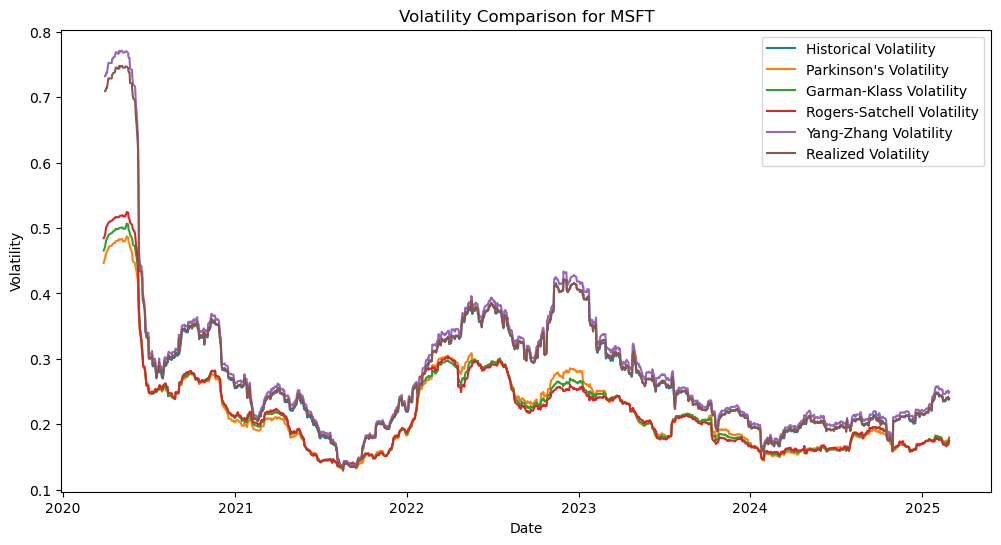

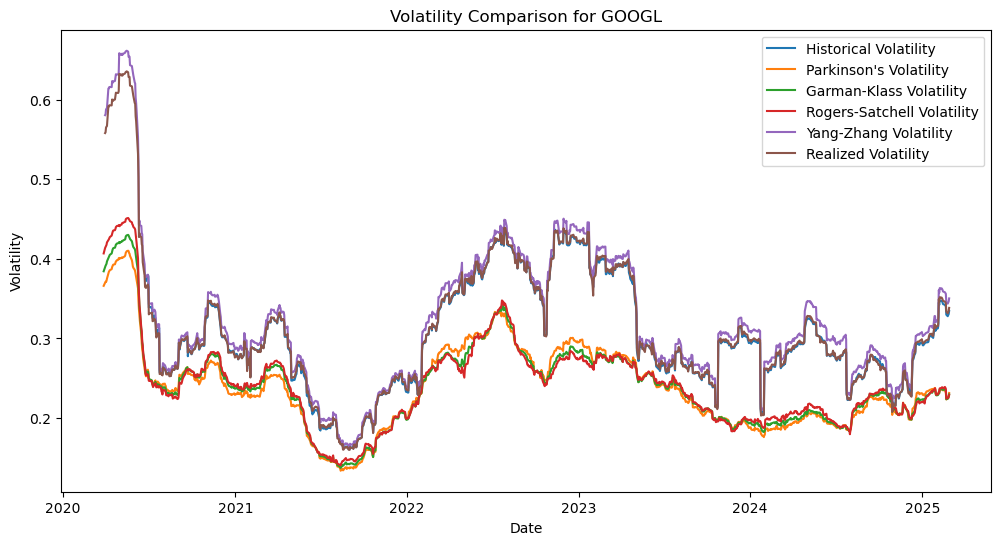

In [17]:
# Plot different volatility estimators for each stock
vol_estimators = {
    'Historical Volatility': hist_vol,
    "Parkinson's Volatility": parkinson_vol,
    'Garman-Klass Volatility': garman_klass_vol,
    'Rogers-Satchell Volatility': rogers_satchell_vol,
    'Yang-Zhang Volatility': yang_zhang_vol,
    'Realized Volatility': realized_vol,
}

for stock in stocks:
    plt.figure(figsize=(12, 6))
    for label, df in vol_estimators.items():
        plt.plot(df.index, df[stock], label=label)
    plt.title(f'Volatility Comparison for {stock}')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend()
    plt.show()

In [18]:
# Risk-Free Rate (Assumed annualized rate, can be updated)
risk_free_rate = 0.02 / 252  # Daily risk-free rate (assuming 2% per year)

In [19]:
# Sharpe Ratio Calculation
def sharpe_ratio(log_returns, window=rolling_window, risk_free_rate=risk_free_rate):
    excess_returns = log_returns - risk_free_rate
    return excess_returns.rolling(window=window).mean() / log_returns.rolling(window=window).std() * np.sqrt(252)

sharpe_ratios = sharpe_ratio(log_returns)

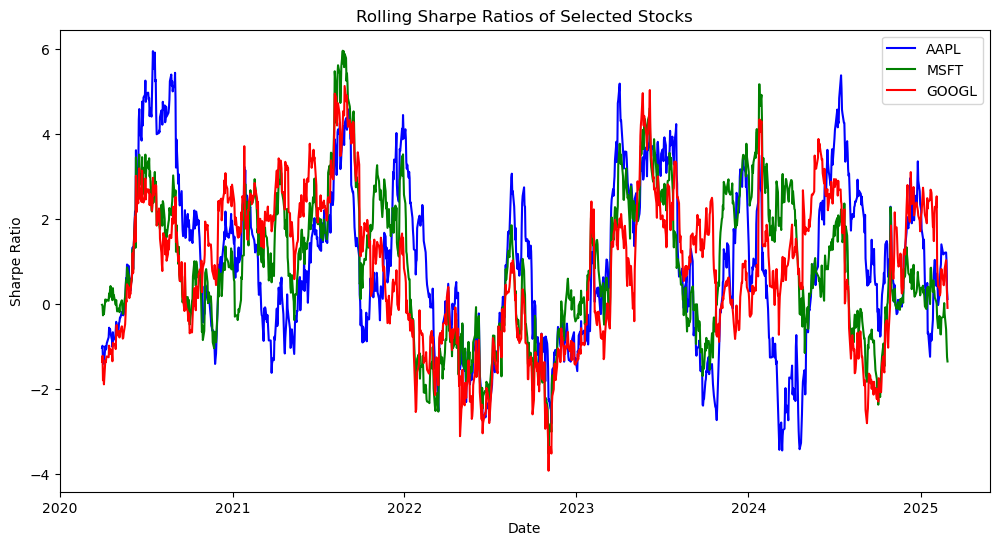

In [20]:
# Plot Sharpe Ratios
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(sharpe_ratios.index, sharpe_ratios[stock], label=stock, color=colors[stock])
plt.title('Rolling Sharpe Ratios of Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.show()

In [21]:
# Find best-performing stock based on mean Sharpe Ratio
mean_sharpe_ratios = sharpe_ratios.mean().sort_values(ascending=False)
print("Best stock to buy based on Sharpe Ratio:")
print(mean_sharpe_ratios)

Best stock to buy based on Sharpe Ratio:
Ticker
AAPL     0.956146
MSFT     0.889199
GOOGL    0.832730
dtype: float64


In [44]:
# Compute Bollinger Bands for AAPL
def bollinger_bands(price, window=rolling_window):
    rolling_mean = price.rolling(window=window).mean()
    rolling_std = price.rolling(window=window).std()
    upper_band = rolling_mean + (2 * rolling_std)
    lower_band = rolling_mean - (2 * rolling_std)
    return rolling_mean, upper_band, lower_band

aapl_mean, aapl_upper, aapl_lower = bollinger_bands(prices['Close']['AAPL'])

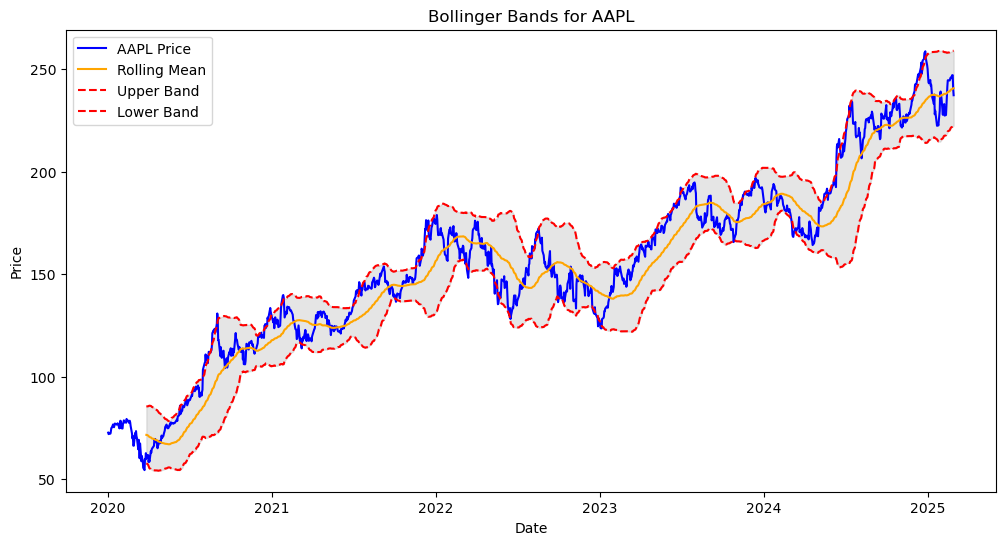

In [46]:
# Plot Bollinger Bands for AAPL
plt.figure(figsize=(12, 6))
plt.plot(prices.index, prices['Close']['AAPL'], label='AAPL Price', color='blue')
plt.plot(prices.index, aapl_mean, label='Rolling Mean', color='orange')
plt.plot(prices.index, aapl_upper, label='Upper Band', linestyle='dashed', color='red')
plt.plot(prices.index, aapl_lower, label='Lower Band', linestyle='dashed', color='red')
plt.fill_between(prices.index, aapl_lower, aapl_upper, color='gray', alpha=0.2)
plt.title('Bollinger Bands for AAPL')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()
